<a href="https://colab.research.google.com/github/SalomeAc/Redes-Entrega1/blob/main/Copia_de_Entrega_2_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub


# Download latest version
path = kagglehub.dataset_download("indk214/brain-tumor-dataset-segmentation-and-classification")

KAGGLE_PATH="/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET"

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-dataset-segmentation-and-classification' dataset.
Path to dataset files: /kaggle/input/brain-tumor-dataset-segmentation-and-classification


## Build YOLO Structure Directories

In [ ]:
"""
Script 1 — Build YOLO folder structure and populate with tumor images (no masks).
           Images are converted to grayscale and resized before saving.

Dataset structure expected:
  DATASET/Segmentation/Glioma/          -> enh_XXXX.png + enh_XXXX_mask.png
  DATASET/Segmentation/Meningioma/      -> ...
  DATASET/Segmentation/Pituitary tumor/ -> ...

Output structure:
  data/
  ├── images/
  │   ├── train/        ← grayscale + resized PNGs
  │   ├── validation/
  │   └── test/
  └── labels/           (empty folders, filled by Script 2)
      ├── train/
      ├── validation/
      └── test/
"""

import cv2
import random
from pathlib import Path

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATASET_PATH = Path(KAGGLE_PATH)
SEG_PATH     = DATASET_PATH / "Segmentation"
OUTPUT_PATH  = Path("data")

TRAIN_RATIO      = 0.70
VALIDATION_RATIO = 0.20
# TEST_RATIO     = 0.10  (remainder)

RANDOM_SEED = 42

# ── PREPROCESSING ─────────────────────────────────────────────────────────────
TARGET_SIZE  = (320, 320)   # (width, height) — change to (416,416) if needed
TO_GRAYSCALE = True         # MRI has no real color info → safe to drop channels
# ─────────────────────────────────────────────────────────────────────────────

CLASSES = {
    "Glioma":          0,
    "Meningioma":      1,
    "Pituitary tumor": 2,
}

random.seed(RANDOM_SEED)

# ── 1. Create output directories ──────────────────────────────────────────────
splits = ["train", "validation", "test"]
for split in splits:
    (OUTPUT_PATH / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUTPUT_PATH / "labels" / split).mkdir(parents=True, exist_ok=True)

print("✅  Folder structure created:")
for split in splits:
    print(f"   data/images/{split}/   data/labels/{split}/")


def preprocess_and_save(src: Path, dst: Path):
    """
    Read src image, optionally convert to grayscale, resize, and save to dst.
    Uses INTER_AREA for downscaling (best quality for shrinking).
    """
    img = cv2.imread(str(src), cv2.IMREAD_GRAYSCALE if TO_GRAYSCALE else cv2.IMREAD_COLOR)
    if img is None:
        print(f"  ⚠️  Could not read: {src}")
        return False

    original_size = (img.shape[1], img.shape[0])  # (w, h)

    # Only resize if the image isn't already the target size
    if original_size != TARGET_SIZE:
        img = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)

    cv2.imwrite(str(dst), img)
    return True


# ── 2. Collect, preprocess and save images per class ─────────────────────────
total_saved   = {"train": 0, "validation": 0, "test": 0}
original_sizes = []   # track to report what sizes we started from

for class_name, class_id in CLASSES.items():
    class_dir = SEG_PATH / class_name

    if not class_dir.exists():
        print(f"\n⚠️  Folder not found, skipping: {class_dir}")
        continue

    # Only tumor images — exclude masks
    all_images = sorted([
        f for f in class_dir.glob("*.png")
        if "_mask" not in f.stem
    ])

    if not all_images:
        print(f"\n⚠️  No images found in {class_dir}")
        continue

    # Sample original size from first image for reporting
    sample = cv2.imread(str(all_images[0]), cv2.IMREAD_GRAYSCALE)
    if sample is not None:
        original_sizes.append((sample.shape[1], sample.shape[0]))

    # Shuffle and split
    random.shuffle(all_images)
    n       = len(all_images)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VALIDATION_RATIO)

    split_map = (
        [("train",      img) for img in all_images[:n_train]] +
        [("validation", img) for img in all_images[n_train:n_train + n_val]] +
        [("test",       img) for img in all_images[n_train + n_val:]]
    )

    for split, src in split_map:
        dst = OUTPUT_PATH / "images" / split / src.name
        if preprocess_and_save(src, dst):
            total_saved[split] += 1

    n_test = n - n_train - n_val
    print(f"\n📂  {class_name}  (class_id={class_id})  |  total={n}")
    print(f"     train={n_train}  val={n_val}  test={n_test}")

# ── 3. Summary ────────────────────────────────────────────────────────────────
orig_str = str(original_sizes[0]) if original_sizes else "unknown"

print("\n" + "─" * 55)
print("✅  Done — images preprocessed and saved.")
print(f"   Original size  : {orig_str}  (w × h)")
print(f"   Saved size     : {TARGET_SIZE}  (w × h)")
print(f"   Grayscale      : {TO_GRAYSCALE}")
print(f"   train          : {total_saved['train']}  images")
print(f"   validation     : {total_saved['validation']}  images")
print(f"   test           : {total_saved['test']}  images")
print(f"   TOTAL          : {sum(total_saved.values())}  images")
print("─" * 55)
print("\n⚡  Labels need NO changes — YOLO coords are normalized (0-1)")
print("   and are resolution-independent.")

✅  Folder structure created:
   data/images/train/   data/labels/train/
   data/images/validation/   data/labels/validation/
   data/images/test/   data/labels/test/

📂  Glioma  (class_id=0)  |  total=554
     train=387  val=110  test=57

📂  Meningioma  (class_id=1)  |  total=708
     train=495  val=141  test=72

📂  Pituitary tumor  (class_id=2)  |  total=930
     train=651  val=186  test=93

───────────────────────────────────────────────────────
✅  Done — images preprocessed and saved.
   Original size  : (512, 512)  (w × h)
   Saved size     : (320, 320)  (w × h)
   Grayscale      : True
   train          : 1533  images
   validation     : 437  images
   test           : 222  images
   TOTAL          : 2192  images
───────────────────────────────────────────────────────

⚡  Labels need NO changes — YOLO coords are normalized (0-1)
   and are resolution-independent.


 ## Extract bounding boxes from segmentation masks and write YOLO labels.

In [ ]:
"""
For each image in data/images/{split}/ this script:
  1. Finds the corresponding mask (enh_XXXX_mask.png) in the original Segmentation folder.
  2. Detects the tumor region via contours on the binary mask.
  3. Converts the bounding box to YOLO normalized format:
        <class_id> <x_center> <y_center> <width> <height>   (all 0-1)
  4. Writes data/labels/{split}/<image_stem>.txt

"""

import cv2
import numpy as np
from pathlib import Path

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATASET_PATH = Path(KAGGLE_PATH)
SEG_PATH     = DATASET_PATH / "Segmentation"
OUTPUT_PATH  = Path("data")

# Must match Script 1 exactly
CLASSES = {
    "Glioma":          0,
    "Meningioma":      1,
    "Pituitary tumor": 2,
}

# Minimum contour area in pixels to discard noise blobs
MIN_CONTOUR_AREA = 50
# ─────────────────────────────────────────────────────────────────────────────


def find_mask_path(image_name: str) -> Path | None:
    """
    Given an image filename (e.g. 'enh_1841.png'), find the matching
    *_mask.png in the Segmentation subfolders.
    """
    stem      = Path(image_name).stem          # e.g. 'enh_1841'
    mask_name = f"{stem}_mask.png"
    for class_name in CLASSES:
        candidate = SEG_PATH / class_name / mask_name
        if candidate.exists():
            return candidate
    return None


def get_class_id_from_image(image_name: str) -> int | None:
    """Return the class_id by checking which Segmentation subfolder owns the image."""
    stem = Path(image_name).stem
    for class_name, class_id in CLASSES.items():
        candidate = SEG_PATH / class_name / f"{stem}.png"
        if candidate.exists():
            return class_id
    return None


def mask_to_yolo_bboxes(mask_path: Path, class_id: int) -> list[str]:
    """
    Read a binary mask and return a list of YOLO annotation strings.
    One string per detected tumor contour.
    """
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []

    h, w = mask.shape

    # Binarize (handles both 0/255 and 0/1 masks)
    _, binary = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    annotations = []
    for cnt in contours:
        if cv2.contourArea(cnt) < MIN_CONTOUR_AREA:
            continue  # skip noise

        x, y, bw, bh = cv2.boundingRect(cnt)

        # Clamp to image bounds (safety)
        x  = max(0, x)
        y  = max(0, y)
        bw = min(bw, w - x)
        bh = min(bh, h - y)

        # Normalize to YOLO format
        x_center = (x + bw / 2) / w
        y_center = (y + bh / 2) / h
        norm_w   = bw / w
        norm_h   = bh / h

        annotations.append(
            f"{class_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}"
        )

    return annotations


# ── Main loop ─────────────────────────────────────────────────────────────────
splits = ["train", "validation", "test"]

stats = {s: {"labeled": 0, "empty": 0, "no_mask": 0} for s in splits}

for split in splits:
    images_dir = OUTPUT_PATH / "images" / split
    labels_dir = OUTPUT_PATH / "labels" / split

    image_files = sorted(images_dir.glob("*.png"))

    if not image_files:
        print(f"⚠️  No images found in {images_dir}, skipping.")
        continue

    for img_path in image_files:
        label_path = labels_dir / (img_path.stem + ".txt")

        # --- Find mask ---
        mask_path = find_mask_path(img_path.name)
        if mask_path is None:
            print(f"  ⚠️  Mask not found for: {img_path.name}")
            label_path.write_text("")          # empty label = no tumor / background
            stats[split]["no_mask"] += 1
            continue

        # --- Get class id ---
        class_id = get_class_id_from_image(img_path.name)
        if class_id is None:
            print(f"  ⚠️  Class not resolved for: {img_path.name}")
            label_path.write_text("")
            stats[split]["no_mask"] += 1
            continue

        # --- Extract bboxes ---
        annotations = mask_to_yolo_bboxes(mask_path, class_id)

        if annotations:
            label_path.write_text("\n".join(annotations) + "\n")
            stats[split]["labeled"] += 1
        else:
            label_path.write_text("")          # mask exists but no contour found
            stats[split]["empty"] += 1
            print(f"  ℹ️  Empty mask (no contour): {img_path.name}")

    print(f"✅  {split:12s}  labeled={stats[split]['labeled']}  "
          f"empty={stats[split]['empty']}  no_mask={stats[split]['no_mask']}")

# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "─" * 55)
print("✅  Label generation complete.")
total_labeled  = sum(s["labeled"]  for s in stats.values())
total_empty    = sum(s["empty"]    for s in stats.values())
total_no_mask  = sum(s["no_mask"]  for s in stats.values())
print(f"   Annotated labels  : {total_labeled}")
print(f"   Empty masks       : {total_empty}")
print(f"   Missing masks     : {total_no_mask}")
print("─" * 55)
print("\nExample label format:  <class_id> <x_center> <y_center> <width> <height>")
print("Classes               :  0=Glioma  1=Meningioma  2=Pituitary tumor")

✅  train         labeled=1533  empty=0  no_mask=0
✅  validation    labeled=437  empty=0  no_mask=0
✅  test          labeled=222  empty=0  no_mask=0

───────────────────────────────────────────────────────
✅  Label generation complete.
   Annotated labels  : 2192
   Empty masks       : 0
   Missing masks     : 0
───────────────────────────────────────────────────────

Example label format:  <class_id> <x_center> <y_center> <width> <height>
Classes               :  0=Glioma  1=Meningioma  2=Pituitary tumor


## Visualize Samples

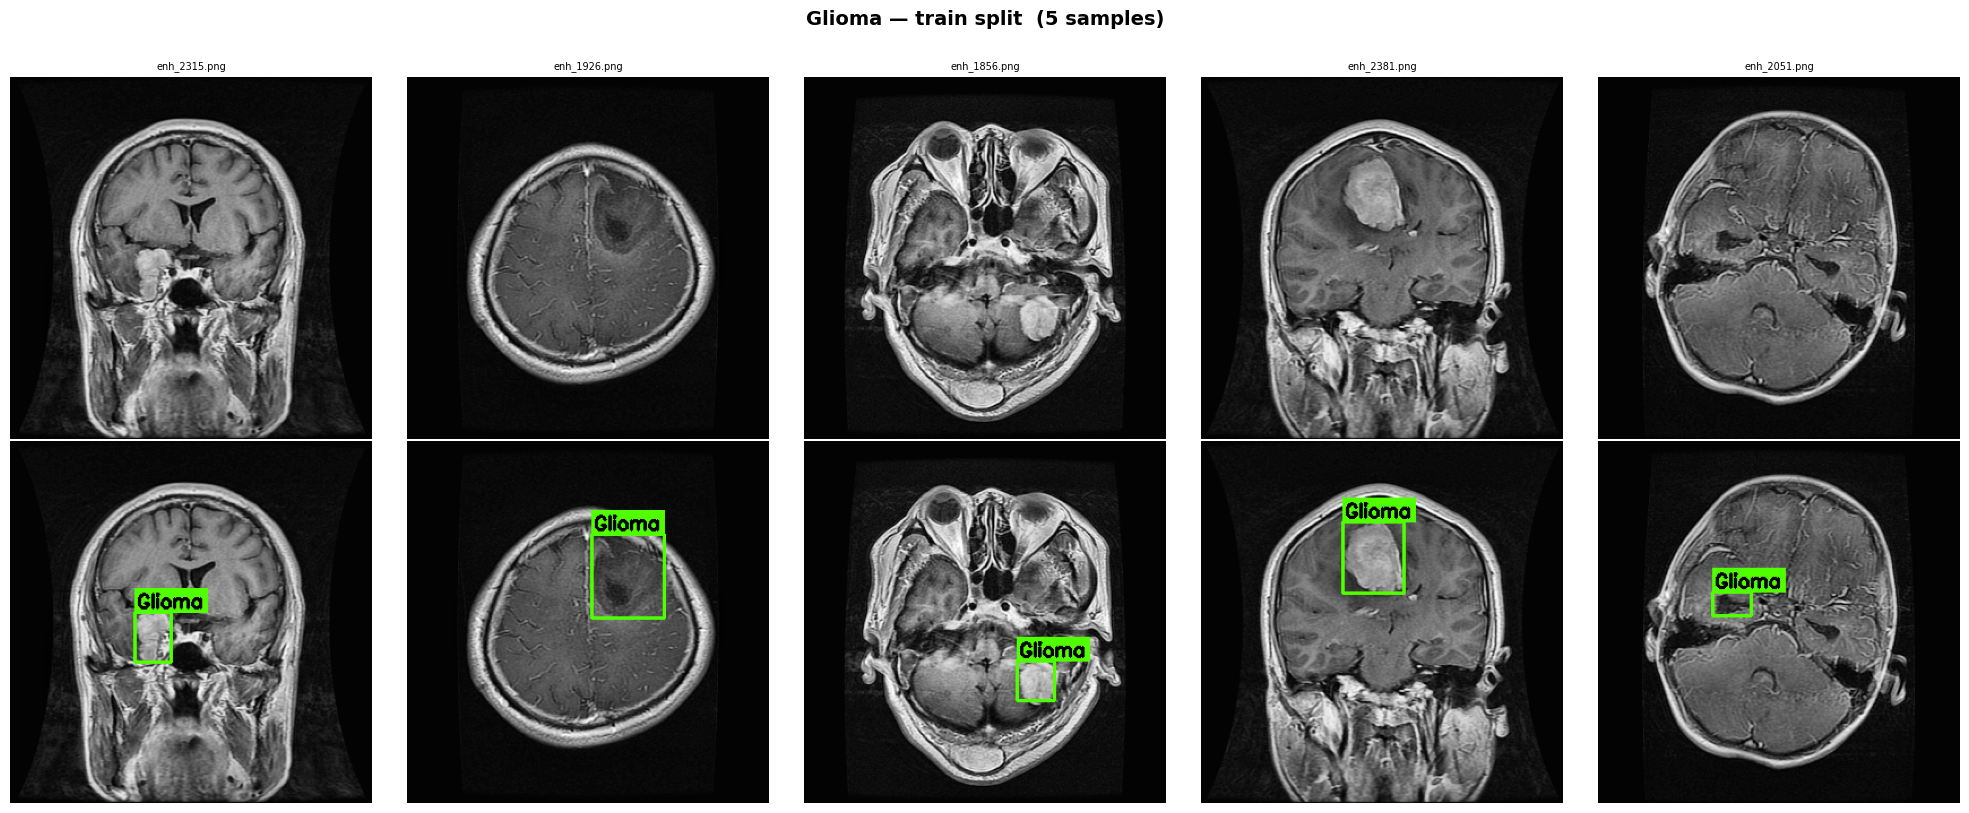

✅  Saved: glioma_bbox_preview.png  (5 images)


In [ ]:
"""
Visualize 5 random Glioma images from data/images/train/ with their YOLO bounding boxes.
Reads the corresponding labels from data/labels/train/.

Layout:
  Row 1: Original MRI  x5
  Row 2: Bbox overlay  x5
"""

import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATA_PATH = Path("data")

CLASS_NAMES  = {0: "Glioma", 1: "Meningioma", 2: "Pituitary Tumor"}
CLASS_COLORS = {0: (0, 255, 80), 1: (255, 180, 0), 2: (0, 180, 255)}  # BGR

SPLIT       = "train"   # "validation" or "test"
N_IMAGES    = 5
RANDOM_SEED = 42        # set to None for a different sample each run
# ─────────────────────────────────────────────────────────────────────────────


def yolo_to_pixel(xc, yc, nw, nh, img_w, img_h):
    """YOLO normalized → pixel (x1, y1, x2, y2)."""
    bw, bh = nw * img_w, nh * img_h
    cx, cy = xc * img_w, yc * img_h
    return int(cx - bw/2), int(cy - bh/2), int(cx + bw/2), int(cy + bh/2)


def load_label(label_path: Path):
    """Parse YOLO .txt → list of (class_id, xc, yc, w, h)."""
    if not label_path.exists() or label_path.stat().st_size == 0:
        return []
    boxes = []
    for line in label_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            boxes.append((int(parts[0]), float(parts[1]), float(parts[2]),
                          float(parts[3]), float(parts[4])))
    return boxes


def draw_boxes(img_bgr, boxes):
    """Return a copy of img_bgr with YOLO boxes drawn."""
    out = img_bgr.copy()
    h, w = out.shape[:2]
    for (cls, xc, yc, nw, nh) in boxes:
        x1, y1, x2, y2 = yolo_to_pixel(xc, yc, nw, nh, w, h)
        color = CLASS_COLORS.get(cls, (255, 255, 255))
        label = CLASS_NAMES.get(cls, f"class_{cls}")
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
        cv2.rectangle(out, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
        cv2.putText(out, label, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 2)
    return out


# ── Collect Glioma images ─────────────────────────────────────────────────────
images_dir = DATA_PATH / "images" / SPLIT
labels_dir = DATA_PATH / "labels" / SPLIT

glioma_images = []
for img_path in sorted(images_dir.glob("*.png")):
    label_path = labels_dir / (img_path.stem + ".txt")
    boxes = load_label(label_path)
    if any(cls == 0 for cls, *_ in boxes):
        glioma_images.append(img_path)

if not glioma_images:
    print("❌  No Glioma images with labels found in", images_dir)
    exit()

if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)

n = min(N_IMAGES, len(glioma_images))
selected = random.sample(glioma_images, n)

# ── Plot grid: 2 rows (original | bbox) × N_IMAGES cols ──────────────────────
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
fig.suptitle(f"Glioma — {SPLIT} split  ({n} samples)", fontsize=14, fontweight="bold", y=1.01)

for col, img_path in enumerate(selected):
    label_path = labels_dir / (img_path.stem + ".txt")
    boxes      = load_label(label_path)

    img_bgr  = cv2.imread(str(img_path))
    img_draw = draw_boxes(img_bgr, boxes)

    # Row 0 — original
    axes[0, col].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(img_path.name, fontsize=7)
    axes[0, col].axis("off")

    # Row 1 — bbox overlay
    axes[1, col].imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
    # Print YOLO coords below each bbox image
    coord_lines = "\n".join(
        f"xc={xc:.3f} yc={yc:.3f}\nw={w:.3f} h={h:.3f}"
        for _, xc, yc, w, h in boxes
    )
    axes[1, col].set_xlabel(coord_lines, fontsize=7, color="#222222",
                             labelpad=6, family="monospace")
    axes[1, col].axis("off")

# Row labels on the left
axes[0, 0].set_ylabel("Original MRI", fontsize=11, labelpad=8)
axes[1, 0].set_ylabel("YOLO BBox",    fontsize=11, labelpad=8)
for ax in axes[:, 0]:
    ax.yaxis.set_visible(True)
    ax.tick_params(left=False, labelleft=False)

plt.tight_layout()
plt.savefig("glioma_bbox_preview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅  Saved: glioma_bbox_preview.png  ({n} images)")

## Create YOLO .yaml file

In [ ]:
%%writefile data.yaml

# data.yaml — YOLOv8 dataset configuration
# Place this file at the same level as the /data folder

path: ./data          # root of the dataset

train: images/train
val:   images/validation
test:  images/test

# Number of classes
nc: 3

# Class names (order must match class_id: 0, 1, 2)
names:
  0: Glioma
  1: Meningioma
  2: Pituitary_tumor

# Training tip:
#   yolo detect train data=data.yaml model=yolov8s.pt epochs=100 imgsz=640



Writing data.yaml


## Train YOLO Model

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 83.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import torch
from datetime import datetime
import os
import shutil


def train_yolo_model(epochs=50, batch_size=16, img_size=640, lr0=0.01,data_yaml_path="data.yaml",base_dir="./",model_save_dir="./"):
    # Check for CUDA availability
    device = '0' if torch.cuda.is_available() else 'cpu'

    # Define timestamp for unique model naming
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_name = f'train_{timestamp}'

    # Load the model
    # try:
    #     model = YOLO('yolo12n.pt')
    #     model_type = 'yolo12n'
    # except Exception:
    model = YOLO('yolov8n.pt')
    model_type = 'yolov8n'

    # Train the model
    results = model.train(
        data=data_yaml_path,
        epochs=epochs,
        batch=batch_size,
        imgsz=img_size,
        patience=10,
        save=True,
        device=device,
        project=os.path.join(base_dir, 'runs'),
        name=run_name,
        lr0=lr0,
        lrf=0.01,
        plots=True,
        save_period=5
    )

    # Save the model
    model_save_path = os.path.join(model_save_dir, f"{model_type}_{timestamp}.pt")

    try:
        # Use the correct method to save the Ultralytics YOLO model
        model.save(model_save_path)
    except Exception as e:
        print(f"Warning: Could not save model using model.save(): {e}")
        # Fallback: copy the best.pt file generated by the training process
        best_model_path = os.path.join(base_dir, 'runs', run_name, 'weights', 'best.pt')
        if os.path.exists(best_model_path):
            shutil.copy2(best_model_path, model_save_path)
            print(f"Copied best model from {best_model_path} to {model_save_path}")
        else:
            print(f"Error: Could not find best.pt at {best_model_path} to save the model.")

    return model

In [ ]:
model = train_yolo_model(epochs=50, batch_size=16, lr0=0.01)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_20260601_221645, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspec

## Validation Model

In [ ]:
def validate_model(model):
    metrics = model.val(
        data='data.yaml',
        split='val',
        project='data',
        name='val'
    )

    # Calculate F1 score using mean precision (mp) and mean recall (mr)
    f1_score = 2 * metrics.box.mp * metrics.box.mr / (metrics.box.mp + metrics.box.mr + 1e-6)
    print(f"Overall F1 Score: {f1_score:.4f}")

    return metrics

In [ ]:
!ls

data			 runs	      yolov8n_20260601_221457.pt
data.yaml		 sample_data  yolov8n_20260601_221645.pt
glioma_bbox_preview.png  yolo26n.pt   yolov8n.pt


In [ ]:
validate_model(model)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1391.2±933.8 MB/s, size: 65.5 KB)
val: Scanning /content/data/labels/validation.cache... 437 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 437/437 166.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 5.2it/s 5.4s
                   all        437        437      0.812      0.788      0.847      0.558
                Glioma        110        110       0.74      0.673      0.755      0.521
            Meningioma        141        141      0.804      0.766      0.829      0.499
       Pituitary_tumor        186        186      0.891      0.925      0.956      0.653
Speed: 1.8ms preprocess, 4.0ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/data/val-2
Overall F1 Score: 0.7997


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7892dcb003e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04